# Run comparisons — embeddings, NER, and combined features, with outputs inline

Runs the exact same comparison logic as `scripts/compare_embeddings.py`,
`scripts/compare_ner_models.py`, and `scripts/compare_combined_features.py` — imported
from those modules, not reimplemented — and shows every table and plot **inline, in this
notebook**. This is now the primary way to run and see this repo's comparisons: clone the
repo, open this notebook, run all cells, and every result and decision this session's
work is based on is right here, computed live from `data/raw/`, not read off a checked-in
file.

`reports/` holds this repo's decision-trail `.md` files (`model_shortlist.md`,
`ner_model_notes.md`, `combined_features_notes.md`, `metrics_rework_and_rerun.md`) — the
narrative of what was tried, why, and what it meant — not a CSV/PNG per run. The three
`compare_*.py` scripts still work standalone from the command line for
scripting/automation, and can still write a file if you explicitly pass
`--out`/`--out-plot`, but neither is the default anymore.

**Scope, same as every comparison script in this repo:** a diagnostic exercise against an
already-labelled dataset, not a classifier-baseline-selection pipeline. Nothing downstream
is wired to whatever "wins" a run of this notebook.


## Setup

Run this notebook from inside `notebooks/experiments/` (same convention as every other
notebook in this repo — see `notebooks/README.md`) so the relative paths below resolve.


In [1]:
import sys
from pathlib import Path

SCRIPTS_DIR = Path("../../scripts").resolve()
DATA_DIR = Path("../../data/raw").resolve()
PROCESSED_DIR = Path("../../data/processed").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
from scipy import stats

# Importing compare_ner_models / compare_combined_features pulls in their module-level
# `matplotlib.use("Agg")` (they're batch scripts, written to save a PNG with no display
# attached) — harmless here, but it means we override the backend to inline AFTER these
# imports, in the next cell, not before.
from embedding_utils import (
    build_label_masks,
    cross_validated_roc_auc,
    drop_empty_rows,
    embed_corpus_and_use_case,
    evaluate_representation,
    get_title_abstract,
    get_use_case_text,
    load_export,
    round_floats,
)
from latent_space_utils import (
    centroid_analysis,
    dispersion_metrics,
    interpret_dispersion,
    plot_model_row,
    project_2d,
)
from compare_ner_models import DEFAULT_SPACY_MODEL, embed_representation, load_spacy_model
from compare_combined_features import concat_blocks

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


In [2]:
%matplotlib inline
# Must come AFTER the imports above (they force the Agg backend for the standalone
# scripts' own PNG-saving use) — this switches the same matplotlib session back to
# Jupyter's inline backend for every plot the rest of this notebook draws.


## Pick a corpus

Two real sources are wired up here:

- **`"soil"`** — `data/raw/high-quality-microbial-and-fungal-community-in-soil-labelledFULLRUN.parquet`,
  the standalone 602-paper export this repo has tested from the start (same corpus as
  `reports/model_shortlist.md`, `reports/ner_model_notes.md`,
  `reports/combined_features_notes.md`, and `reports/metrics_rework_and_rerun.md`).
- **`"combined"`** — `data/processed/papers_combined.parquet`, 2,873 papers across 6 real
  research questions in one file (see `data/processed/README.md`). Set `USE_CASE_KEY` to
  pick which one: `cement_binders`, `soil_microbiome`, `ner`, `solar_leo`,
  `carbon_capture`, `tech_forecasting`. This file also carries each research question's
  actual objective and required/nice-to-have search terms, so the notebook builds the
  RICHER use-case text straight from those columns (see `build_richer_use_case_text`
  below) instead of a short placeholder name — no separate `.usecase.json` file needed,
  unlike the standalone soil export.

**Retired:** the old "climate/agriculture" placeholder corpus
(`data/raw/sample-export.parquet`) has been removed from this repo. It was a 100-paper
file used to start testing before this project had real use-case briefs — it carried no
real use-case text (just a generic short name) and too few observations to trust a
comparison drawn from it. Its historical numbers stay in the `.md` reports for the
record, but that file is gone and shouldn't come back; don't use it for future
comparisons.

**A timing note before you pick a corpus:** `cement_binders` (690 papers) and
`soil_microbiome`/`"soil"` (602 papers either way you load it) are the two biggest, and
Specter/bge-small (2 of the 4 default embedding models) are the slow ones on CPU — expect
the embedding comparison section to take several minutes on either. The NER and combined
sections stay fast regardless of corpus (spaCy's small pipeline, plus one fast embedding
model).


In [3]:
# The former "soil" corpus was a standalone per-use-case *parquet* export that is no
# longer in the repo — data/raw/ now holds the JSONL exports, and every use case is
# reachable from papers_combined.parquet instead. Filtering the combined file to
# soil_microbiome gives the identical 602-paper corpus, so the toggle below is now
# "which research question", not "which file".
CORPORA = {
    "combined": {
        "path": PROCESSED_DIR / "papers_combined.parquet",
        "label": "papers_combined.parquet (6 research questions in one file)",
    },
}

CORPUS_KEY = "combined"           # <- only "combined" now; see the note above
USE_CASE_KEY = "soil_microbiome"  # <- which research question to analyse; one of
                                   #    cement_binders, soil_microbiome, ner, solar_leo,
                                   #    carbon_capture, tech_forecasting

corpus = CORPORA[CORPUS_KEY]
print(f"Selected corpus: {corpus['label']}  ({corpus['path'].name})")
if CORPUS_KEY == "combined":
    print(f"  filtered to use_case_key={USE_CASE_KEY!r}")


Selected corpus: papers_combined.parquet (6 research questions in one file)  (papers_combined.parquet)
  filtered to use_case_key='soil_microbiome'


In [4]:
LABEL_COL = "triage_label"


def build_richer_use_case_text(df_slice):
    """objective + terms_must_include + terms_nice_to_have, space-joined — the same
    recipe already used for the soil corpus's real .usecase.json (see
    `reports/model_shortlist.md` §4b), built here directly from papers_combined.parquet's
    own research-brief columns instead of a separate hand-authored file. Every row for a
    given use_case_key carries the identical brief, so the first row is enough."""
    row = df_slice.iloc[0]
    parts = [str(row["objective"])]
    for col in ("terms_must_include", "terms_nice_to_have"):
        val = row.get(col)
        if val is None:
            continue
        parts.extend(str(v) for v in list(val) if v)
    return " ".join(parts)


if CORPUS_KEY == "soil":
    df = load_export(corpus["path"])
    titles, abstracts = get_title_abstract(df)
    df, titles, abstracts = drop_empty_rows(df, titles, abstracts)
    use_case_text = get_use_case_text(df, "use_case", override=None)

elif CORPUS_KEY == "combined":
    full_df = load_export(corpus["path"])
    valid_keys = sorted(full_df["use_case_key"].unique())
    if USE_CASE_KEY not in valid_keys:
        raise ValueError(f"USE_CASE_KEY={USE_CASE_KEY!r} not in {valid_keys}")
    df = full_df[full_df["use_case_key"] == USE_CASE_KEY].reset_index(drop=True)
    titles, abstracts = get_title_abstract(df)
    df, titles, abstracts = drop_empty_rows(df, titles, abstracts)
    use_case_text = build_richer_use_case_text(df)

else:
    raise ValueError(f"Unknown CORPUS_KEY: {CORPUS_KEY!r}")

masks = build_label_masks(df, LABEL_COL)
print(f"{len(df)} papers. Use case text: \"{use_case_text}\"")
print(f"Labels: {masks['n_pos']} positive, {masks['n_neg']} negative, {masks['n_pass']} pass")


602 papers. Use case text: "Identify research on microbial and fungal community management strategies that enhance soil health, crop productivity, and resistance to extreme heat and flooding stress. soil microbial community soil fungal community soil health crop production heat stress resistance flood stress resistance soil microbial injection soil fungal injection soil microbial engineering soil fungal engineering mycorrhizal fungi rhizosphere microbiome plant growth-promoting bacteria soil microbiome biocontrol"
Labels: 94 positive, 263 negative, 245 pass


## 1. Embedding models

Same 4 models `scripts/compare_embeddings.py` runs by default (see
`reports/model_shortlist.md` §1-3 for why these 4): a domain-specific model (Specter), a
corrected-prefix asymmetric model (bge-small), the agent's own current default as the
control (paraphrase-multilingual), and the tiny/fast floor (all-MiniLM-L6-v2).

Every representation in this notebook is scored the same reworked way — see
`reports/metrics_rework_and_rerun.md` for the full reasoning, in short:
- **`roc_auc_strict` / `roc_auc_conservative`** — cross-validated classifier AUC on paper
  vectors alone (the use-case vector never enters this number), under two label readings:
  strict (positive vs. negative only) and conservative (positive vs. negative+pass, the
  harsher reading a deployed tool can't dodge). Each comes with `_std` — the spread ACROSS
  folds, not just the mean, so "these two numbers are basically the same" is checkable
  instead of asserted.
- **`query_auc_*` / `recall_at_10pct` / `recall_at_20pct` / `wss_at_95`** — rank papers by
  cosine similarity to the USE-CASE VECTOR ITSELF (what `roc_auc` never looks at), scored
  against the same two label readings.
- **`use_case_discriminative_gap`** — is the use case's wording closer to the papers that
  got KEPT than to the ones that got REJECTED (label-aware), vs. the plain corpus-wide
  centrality percentile (label-blind) already in this repo before the rework.


Embedding with sentence-transformers/allenai-specter ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7410.10it/s]

Embedding with BAAI/bge-small-en-v1.5 ...


Embedding with sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 ...


Embedding with sentence-transformers/all-MiniLM-L6-v2 ...


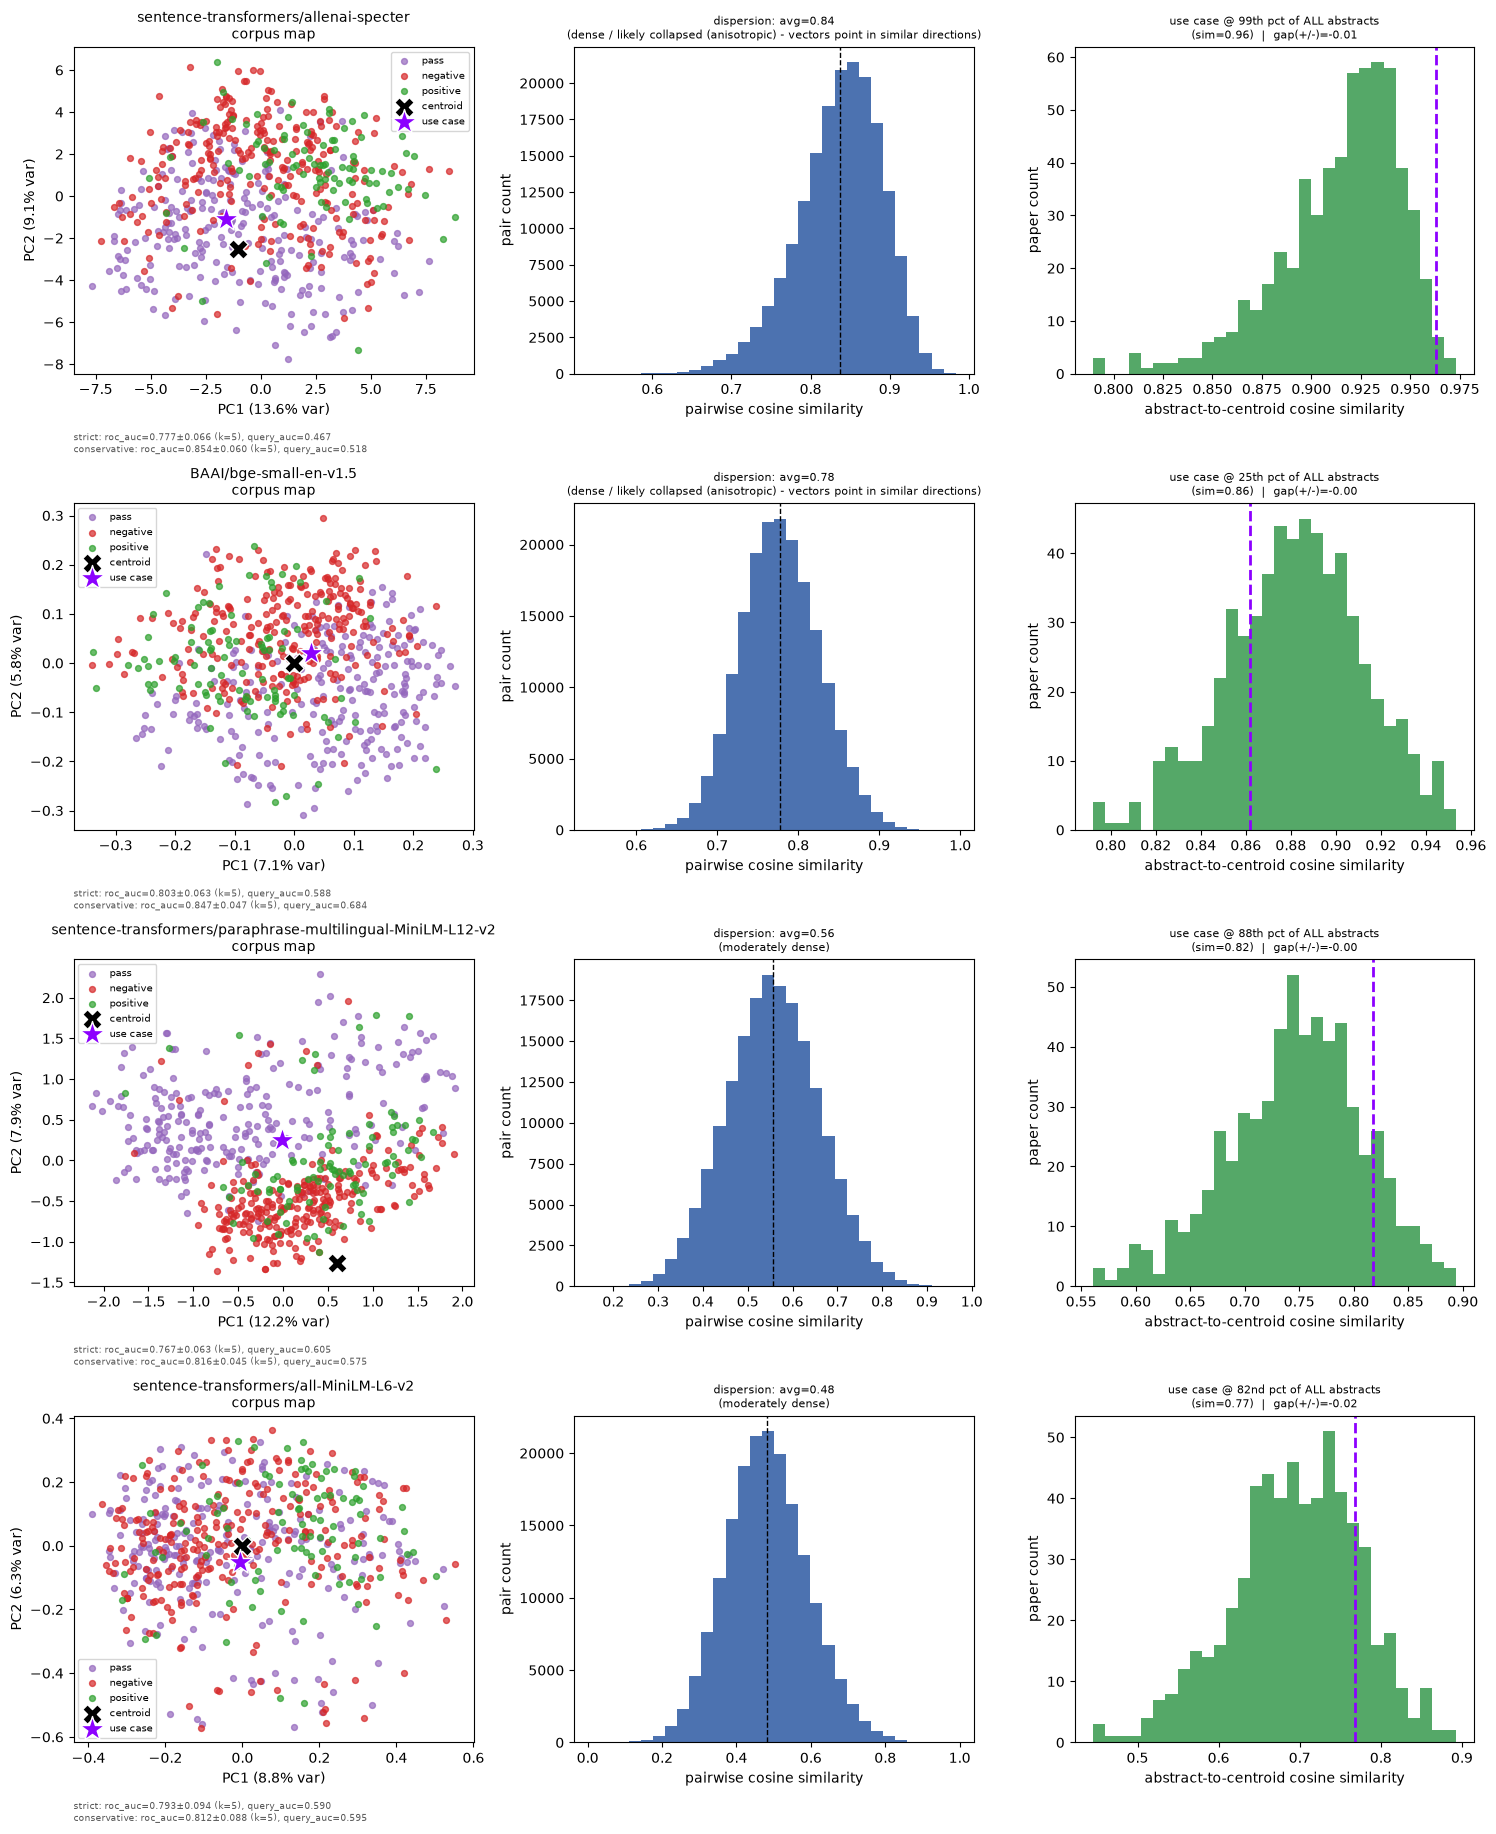

In [5]:
DEFAULT_MODELS = [
    "sentence-transformers/allenai-specter",
    "BAAI/bge-small-en-v1.5",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "sentence-transformers/all-MiniLM-L6-v2",
]

embedding_rows = []
embedding_fold_aucs = {}  # model -> strict fold_aucs, for the paired test in section 4
fig_e, axes_e = __import__("matplotlib.pyplot", fromlist=["subplots"]).subplots(
    len(DEFAULT_MODELS), 3, figsize=(15, 4.6 * len(DEFAULT_MODELS)), squeeze=False
)

for row_idx, model_name in enumerate(DEFAULT_MODELS):
    print(f"Embedding with {model_name} ...")
    paper_vectors, use_case_vec, elapsed = embed_corpus_and_use_case(model_name, titles, abstracts, use_case_text)

    disp = dispersion_metrics(paper_vectors)
    cent = centroid_analysis(paper_vectors, use_case_vec, masks["pos_mask"], masks["neg_mask"])
    metrics = evaluate_representation(paper_vectors, use_case_vec, masks)

    if masks["strict_mask"].sum() >= 6:
        embedding_fold_aucs[model_name] = cross_validated_roc_auc(
            paper_vectors[masks["strict_mask"]], masks["strict_y"][masks["strict_mask"]]
        )["fold_aucs"]

    coords_2d, uc_xy, centroid_xy, var_ratio = project_2d(paper_vectors, use_case_vec, cent["centroid"], "pca")
    plot_model_row(axes_e[row_idx], model_name, df, LABEL_COL, coords_2d, uc_xy, centroid_xy, var_ratio, disp, cent, metrics)

    embedding_rows.append({
        "model": model_name, "dim": paper_vectors.shape[1], "embed_seconds": round(elapsed, 2),
        **round_floats({
            "avg_pairwise_cosine": disp["avg_pairwise_cosine"],
            "use_case_centroid_percentile": cent["use_case_centroid_percentile"],
            "use_case_discriminative_gap": cent["use_case_discriminative_gap"],
            **metrics,
        }),
    })

fig_e.tight_layout()
embedding_df = pd.DataFrame(embedding_rows)


In [6]:
embedding_df[[
    "model", "dim", "embed_seconds", "avg_pairwise_cosine", "use_case_centroid_percentile",
    "use_case_discriminative_gap", "roc_auc_strict", "roc_auc_strict_std",
    "query_auc_strict", "wss_at_95_strict", "roc_auc_conservative",
]]


,model,dim,embed_seconds,avg_pairwise_cosine,use_case_centroid_percentile,use_case_discriminative_gap,roc_auc_strict,roc_auc_strict_std,query_auc_strict,wss_at_95_strict,roc_auc_conservative
0,sentence-transformers/allenai-specter,768,27.84,0.8367,98.5050,-0.0142,0.7771,0.0665,0.4666,-0.0164,0.8544
1,BAAI/bge-small-en-v1.5,384,116.13,0.7778,24.7508,-0.0019,0.8028,0.0634,0.5878,-0.0080,0.8474
2,sentence-transformers/paraphrase-multilingual-...,384,18.60,0.5568,88.2060,-0.0026,0.7674,0.0628,0.6054,-0.0108,0.8160
3,sentence-transformers/all-MiniLM-L6-v2,384,9.33,0.4821,82.2259,-0.0184,0.7930,0.0939,0.5903,0.0340,0.8119


**Finding (hard numbers, read them off the table above for the corpus you selected):**
`roc_auc_strict` and `query_auc_strict` are on the same 0.5–1.0 scale but answer different
questions (query-blind classifier separability vs. query-conditioned ranking) — a model
that looks strong on one and weak on the other is a real, informative disagreement, not
noise. `roc_auc_strict_std` tells you whether a gap between two models' `roc_auc_strict`
is bigger than fold-to-fold noise; a difference smaller than either model's own `_std` is
a judgement call to treat as "no detectable difference on this evidence", not a ranking.


## 2. NER-derived representations

Same two representations as `scripts/compare_ner_models.py`: `entity_type_counts` (an
18-dim type-mix profile) and `entity_text_tfidf` (TF-IDF+SVD over the actual entity text
spans) — see `reports/ner_model_notes.md` for the full reasoning. `query_auc` matters
most here: if the use case's own text produces zero spaCy entities (a known failure mode
on a short use-case NAME, see `ner_model_notes.md` §4), the use-case vector is all-zero,
`query_auc` should come back at exactly chance (0.5) since a zero vector carries no
ranking signal — a second, independent confirmation of the same degenerate case the old
centrality percentile already flagged (0th percentile), from a metric that actually
involves the labels.


Loading spaCy model en_core_web_sm ...


Building representation 'entity_type_counts' ...


Building representation 'entity_text_tfidf' ...


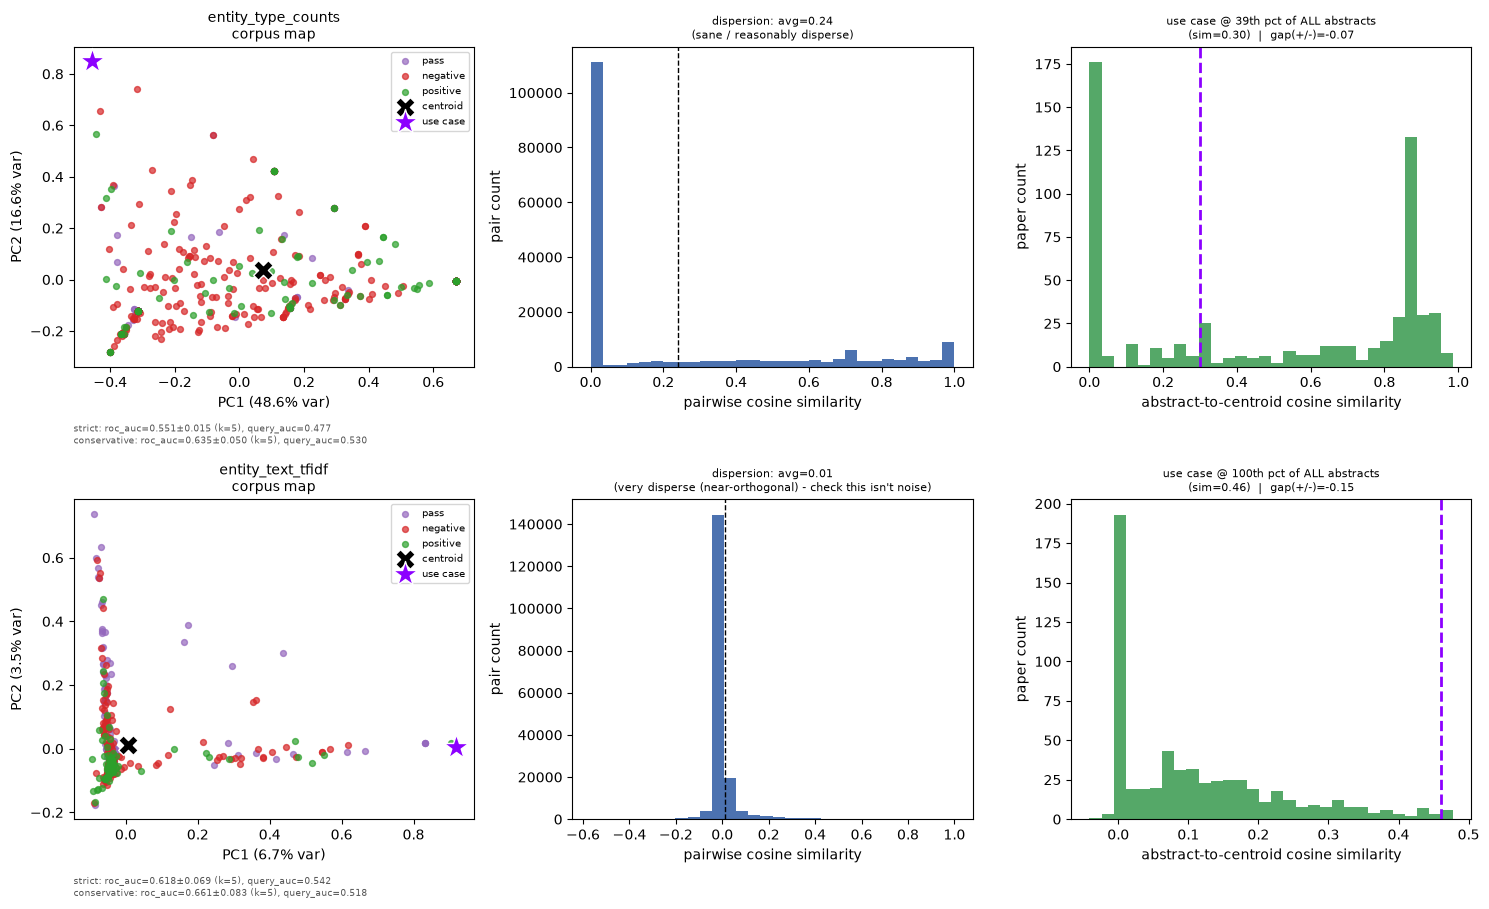

In [7]:
DEFAULT_NER_REPRESENTATIONS = ["entity_type_counts", "entity_text_tfidf"]

print(f"Loading spaCy model {DEFAULT_SPACY_MODEL} ...")
nlp = load_spacy_model(DEFAULT_SPACY_MODEL)
label_vocab = list(nlp.get_pipe("ner").labels)

ner_rows = []
ner_fold_aucs = {}
fig_n, axes_n = __import__("matplotlib.pyplot", fromlist=["subplots"]).subplots(
    len(DEFAULT_NER_REPRESENTATIONS), 3, figsize=(15, 4.6 * len(DEFAULT_NER_REPRESENTATIONS)), squeeze=False
)

for row_idx, rep_name in enumerate(DEFAULT_NER_REPRESENTATIONS):
    print(f"Building representation '{rep_name}' ...")
    paper_vectors, use_case_vec, elapsed, extra = embed_representation(rep_name, nlp, label_vocab, titles, abstracts, use_case_text)

    disp = dispersion_metrics(paper_vectors)
    cent = centroid_analysis(paper_vectors, use_case_vec, masks["pos_mask"], masks["neg_mask"])
    metrics = evaluate_representation(paper_vectors, use_case_vec, masks)

    if masks["strict_mask"].sum() >= 6:
        ner_fold_aucs[rep_name] = cross_validated_roc_auc(
            paper_vectors[masks["strict_mask"]], masks["strict_y"][masks["strict_mask"]]
        )["fold_aucs"]

    coords_2d, uc_xy, centroid_xy, var_ratio = project_2d(paper_vectors, use_case_vec, cent["centroid"], "pca")
    plot_model_row(axes_n[row_idx], rep_name, df, LABEL_COL, coords_2d, uc_xy, centroid_xy, var_ratio, disp, cent, metrics)

    ner_rows.append({
        "representation": rep_name, "dim": paper_vectors.shape[1],
        "n_zero_entity_papers": extra["n_zero_entity_papers"],
        **round_floats({
            "avg_pairwise_cosine": disp["avg_pairwise_cosine"],
            "use_case_centroid_percentile": cent["use_case_centroid_percentile"],
            "use_case_discriminative_gap": cent["use_case_discriminative_gap"],
            **metrics,
        }),
    })

fig_n.tight_layout()
ner_df = pd.DataFrame(ner_rows)


In [8]:
ner_df[[
    "representation", "dim", "n_zero_entity_papers", "avg_pairwise_cosine",
    "use_case_centroid_percentile", "roc_auc_strict", "roc_auc_strict_std",
    "query_auc_strict", "wss_at_95_strict",
]]


,representation,dim,n_zero_entity_papers,avg_pairwise_cosine,use_case_centroid_percentile,roc_auc_strict,roc_auc_strict_std,query_auc_strict,wss_at_95_strict
0,entity_type_counts,18,172,0.2398,38.7043,0.5510,0.0146,0.4773,0.0032
1,entity_text_tfidf,100,172,0.0116,99.6678,0.6184,0.0693,0.5417,0.0172


**Finding:** compare `query_auc_strict` here against the embedding models' `query_auc_strict`
in section 1 — that comparison, not `roc_auc_strict` alone, is the closer match to
"which representation would actually rank the right papers near the top for this query",
since both numbers now involve the query. Whether NER ends up close to or far from the
embeddings on THIS metric (as opposed to the classifier-AUC gap already documented in
`ner_model_notes.md`) is the new information this rework adds — read it off the table
above rather than assuming it repeats the classifier-AUC gap.


## 3. Combined: embedding + NER concatenated

Same recipe as `scripts/compare_combined_features.py`: L2-normalise the embedding block
and the NER block independently, then concatenate (a deliberate 50/50 weighting, not a
tuned hyperparameter — see `reports/combined_features_notes.md`). Default embedding
block is the agent's own current default model, same convenience-default reasoning as
the script.


Embedding with sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 ...


Building combined representation 'paraphrase-multilingual-MiniLM-L12-v2 + entity_type_counts' ...


Building combined representation 'paraphrase-multilingual-MiniLM-L12-v2 + entity_text_tfidf' ...


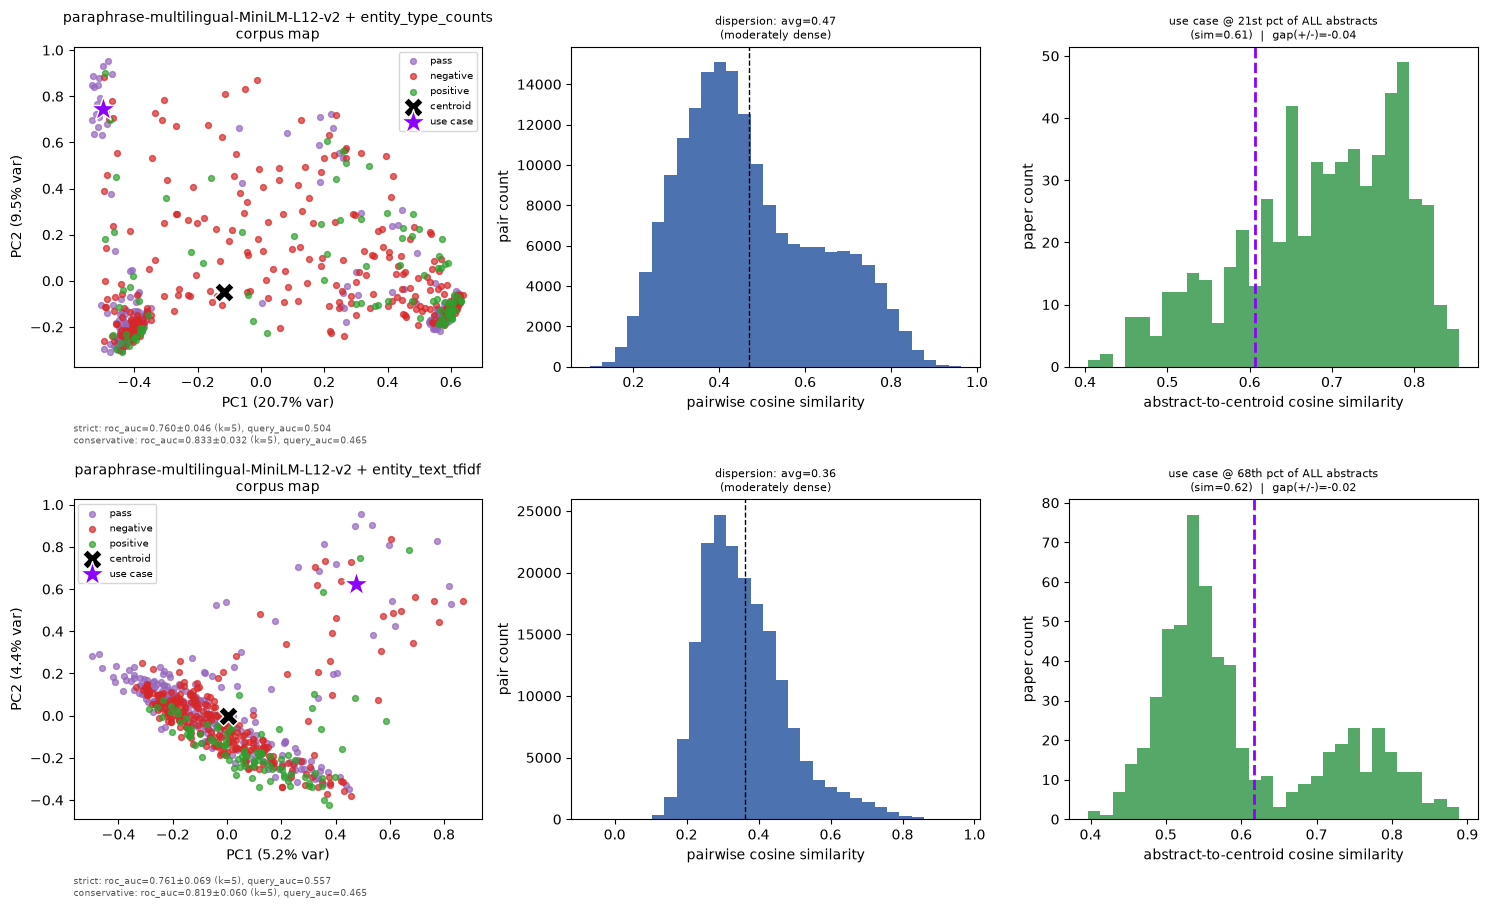

In [9]:
DEFAULT_EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print(f"Embedding with {DEFAULT_EMBEDDING_MODEL} ...")
embedding_papers, embedding_use_case, embed_elapsed = embed_corpus_and_use_case(
    DEFAULT_EMBEDDING_MODEL, titles, abstracts, use_case_text
)

combined_rows = []
combined_fold_aucs = {}
fig_c, axes_c = __import__("matplotlib.pyplot", fromlist=["subplots"]).subplots(
    len(DEFAULT_NER_REPRESENTATIONS), 3, figsize=(15, 4.6 * len(DEFAULT_NER_REPRESENTATIONS)), squeeze=False
)

for row_idx, ner_rep_name in enumerate(DEFAULT_NER_REPRESENTATIONS):
    row_label = f"{DEFAULT_EMBEDDING_MODEL.split('/')[-1]} + {ner_rep_name}"
    print(f"Building combined representation '{row_label}' ...")
    ner_papers, ner_use_case, ner_elapsed, extra = embed_representation(ner_rep_name, nlp, label_vocab, titles, abstracts, use_case_text)
    paper_vectors, use_case_vec = concat_blocks(embedding_papers, embedding_use_case, ner_papers, ner_use_case)

    disp = dispersion_metrics(paper_vectors)
    cent = centroid_analysis(paper_vectors, use_case_vec, masks["pos_mask"], masks["neg_mask"])
    metrics = evaluate_representation(paper_vectors, use_case_vec, masks)

    if masks["strict_mask"].sum() >= 6:
        combined_fold_aucs[row_label] = cross_validated_roc_auc(
            paper_vectors[masks["strict_mask"]], masks["strict_y"][masks["strict_mask"]]
        )["fold_aucs"]

    coords_2d, uc_xy, centroid_xy, var_ratio = project_2d(paper_vectors, use_case_vec, cent["centroid"], "pca")
    plot_model_row(axes_c[row_idx], row_label, df, LABEL_COL, coords_2d, uc_xy, centroid_xy, var_ratio, disp, cent, metrics)

    combined_rows.append({
        "combination": row_label, "dim": paper_vectors.shape[1],
        **round_floats({
            "avg_pairwise_cosine": disp["avg_pairwise_cosine"],
            "use_case_centroid_percentile": cent["use_case_centroid_percentile"],
            "use_case_discriminative_gap": cent["use_case_discriminative_gap"],
            **metrics,
        }),
    })

fig_c.tight_layout()
combined_df = pd.DataFrame(combined_rows)


In [10]:
combined_df[[
    "combination", "dim", "avg_pairwise_cosine", "use_case_centroid_percentile",
    "roc_auc_strict", "roc_auc_strict_std", "query_auc_strict", "wss_at_95_strict",
]]


,combination,dim,avg_pairwise_cosine,use_case_centroid_percentile,roc_auc_strict,roc_auc_strict_std,query_auc_strict,wss_at_95_strict
0,paraphrase-multilingual-MiniLM-L12-v2 + entity...,402,0.4696,20.9302,0.7599,0.0462,0.5036,-0.0052
1,paraphrase-multilingual-MiniLM-L12-v2 + entity...,484,0.3614,68.1063,0.7607,0.0688,0.5568,-0.0024


## 4. Is "embedding alone beats combined" actually significant, or fold noise?

`reports/combined_features_notes.md` called a 0.006–0.008 `roc_auc` gap "well inside
cross-validation noise for n_folds=5" — asserted, not checked, because the per-fold AUCs
that would let you check it were computed and then thrown away (`cross_validated_roc_auc`
used to return only the mean). They're not thrown away anymore — `fold_aucs` is exposed,
and because `StratifiedKFold(shuffle=False)` makes fold membership depend only on the
label vector `y` (never on the representation `X`), every representation scored against
the *same* corpus + label column lands the SAME rows in fold *i* — which means the folds
are already paired across representations, and a **paired** test (each fold vs. its
counterpart, not the two mean AUCs against each other) is the correct one, not an
unpaired comparison.

This is a single-corpus, single-run paired t-test on 5 paired observations — informative
about internal consistency on THIS corpus, not a substitute for a held-out replication
study. Treat a low p-value here as "the fold-to-fold pattern is unlikely to be pure
chance," not as statistical proof the effect generalises.


In [11]:
paired_candidates = {**embedding_fold_aucs, **ner_fold_aucs, **combined_fold_aucs}
names = list(paired_candidates.keys())
print(f"Representations with usable fold_aucs on this corpus: {names}\n")

pairs = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = paired_candidates[names[i]], paired_candidates[names[j]]
        if len(a) != len(b) or len(a) < 2:
            continue
        diffs = np.array(a) - np.array(b)
        t_stat, p_value = stats.ttest_rel(a, b)
        pairs.append({
            "a": names[i], "b": names[j],
            "mean_auc_a": round(float(np.mean(a)), 4), "mean_auc_b": round(float(np.mean(b)), 4),
            "mean_diff": round(float(diffs.mean()), 4), "std_diff": round(float(diffs.std(ddof=1)), 4),
            "paired_t": round(float(t_stat), 3), "paired_p": round(float(p_value), 4),
        })

paired_df = pd.DataFrame(pairs).sort_values("paired_p") if pairs else pd.DataFrame()
paired_df


Representations with usable fold_aucs on this corpus: ['sentence-transformers/allenai-specter', 'BAAI/bge-small-en-v1.5', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'sentence-transformers/all-MiniLM-L6-v2', 'entity_type_counts', 'entity_text_tfidf', 'paraphrase-multilingual-MiniLM-L12-v2 + entity_type_counts', 'paraphrase-multilingual-MiniLM-L12-v2 + entity_text_tfidf']



,a,b,mean_auc_a,mean_auc_b,mean_diff,std_diff,paired_t,paired_p
7,BAAI/bge-small-en-v1.5,sentence-transformers/paraphrase-multilingual-...,0.8028,0.7674,0.0354,0.0094,8.383,0.0011
23,entity_type_counts,paraphrase-multilingual-MiniLM-L12-v2 + entity...,0.5510,0.7599,-0.2088,0.0563,-8.297,0.0012
9,BAAI/bge-small-en-v1.5,entity_type_counts,0.8028,0.5510,0.2518,0.0813,6.928,0.0023
3,sentence-transformers/allenai-specter,entity_type_counts,0.7771,0.5510,0.2260,0.0798,6.332,0.0032
14,sentence-transformers/paraphrase-multilingual-...,entity_type_counts,0.7674,0.5510,0.2164,0.0793,6.101,0.0037
24,entity_type_counts,paraphrase-multilingual-MiniLM-L12-v2 + entity...,0.5510,0.7607,-0.2096,0.0897,-5.226,0.0064
18,sentence-transformers/all-MiniLM-L6-v2,entity_type_counts,0.7930,0.5510,0.2419,0.1150,4.705,0.0093
26,entity_text_tfidf,paraphrase-multilingual-MiniLM-L12-v2 + entity...,0.6184,0.7607,-0.1423,0.0679,-4.687,0.0094
10,BAAI/bge-small-en-v1.5,entity_text_tfidf,0.8028,0.6184,0.1844,0.0962,4.288,0.0128
4,sentence-transformers/allenai-specter,entity_text_tfidf,0.7771,0.6184,0.1587,0.0916,3.873,0.0179


**Finding:** read `paired_p` against a conventional 0.05 threshold as a judgement-call
flag, not a verdict — with only 5 paired folds this test has limited power, so a p-value
above 0.05 here means "not detectably different on this evidence," not "proven equal."
Whatever this table shows for the corpus you selected, cross-check it against the
narrative claims in `reports/model_shortlist.md`, `reports/ner_model_notes.md`, and
`reports/combined_features_notes.md` — this is the check those reports' "noise-level"
and "meaningfully weaker" claims never had until this rework.


## Everything this notebook covers, in one table

Convenience view — every representation run above, one row each, the columns most worth
scanning together. Full detail (recall@k, both label readings, dispersion/PCA numbers)
is in `embedding_df` / `ner_df` / `combined_df` above.


In [12]:
summary_cols = ["name", "roc_auc_strict", "roc_auc_strict_std", "query_auc_strict", "wss_at_95_strict", "use_case_discriminative_gap"]

summary_df = pd.concat([
    embedding_df.rename(columns={"model": "name"})[summary_cols],
    ner_df.rename(columns={"representation": "name"})[summary_cols],
    combined_df.rename(columns={"combination": "name"})[summary_cols],
], ignore_index=True)
summary_df


,name,roc_auc_strict,roc_auc_strict_std,query_auc_strict,wss_at_95_strict,use_case_discriminative_gap
0,sentence-transformers/allenai-specter,0.7771,0.0665,0.4666,-0.0164,-0.0142
1,BAAI/bge-small-en-v1.5,0.8028,0.0634,0.5878,-0.0080,-0.0019
2,sentence-transformers/paraphrase-multilingual-...,0.7674,0.0628,0.6054,-0.0108,-0.0026
3,sentence-transformers/all-MiniLM-L6-v2,0.7930,0.0939,0.5903,0.0340,-0.0184
4,entity_type_counts,0.5510,0.0146,0.4773,0.0032,-0.0696
5,entity_text_tfidf,0.6184,0.0693,0.5417,0.0172,-0.1474
6,paraphrase-multilingual-MiniLM-L12-v2 + entity...,0.7599,0.0462,0.5036,-0.0052,-0.0376
7,paraphrase-multilingual-MiniLM-L12-v2 + entity...,0.7607,0.0688,0.5568,-0.0024,-0.0167


## That's it — no files needed

Everything above ran live from `data/raw/`, straight into this notebook. `reports/` in
this repo holds the decision-trail `.md` files (`model_shortlist.md`, `ner_model_notes.md`,
`combined_features_notes.md`, `metrics_rework_and_rerun.md`) — the narrative of what was
tried and what it meant — not a per-run CSV/PNG for every corpus x representation
combination. If a future decision needs a number quoted in one of those `.md` files,
re-run this notebook rather than looking for a checked-in file; the numbers here ARE the
source of truth, not a snapshot of one.

`scripts/compare_embeddings.py` / `compare_ner_models.py` / `compare_combined_features.py`
still work as standalone CLIs for scripting/automation (`--out`/`--out-plot` will write a
file if you explicitly want one) — this notebook is the same underlying code, just run
interactively with everything visible at once.
